In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# GPU Memory Growth Setup
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU Memory Growth Enabled")
    except RuntimeError as e:
        print(e)
        
from config import Config
from scene_engine import setup_scene
from channel_analyzer import compute_batch_paths, get_ofdm_channel, compute_spatial_covariance
from dataset_exporter import save_dataset


2026-07-27 13:21:26.796318: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


GPU Memory Growth Enabled


jitc_llvm_init(): LLVM API initialization failed ..


In [2]:
config = Config()
scene, bs, ue, pos_tensor = setup_scene(config)
print("Trajectory shape:", pos_tensor.shape)

Trajectory shape: (50, 3)


I0000 00:00:1785158490.291483  497662 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21712 MB memory:  -> device: 0, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:81:00.0, compute capability: 8.9
I0000 00:00:1785158490.294968  497662 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 21938 MB memory:  -> device: 1, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:c1:00.0, compute capability: 8.9
I0000 00:00:1785158490.296541  497662 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 46117 MB memory:  -> device: 2, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:c2:00.0, compute capability: 8.9


In [3]:
paths = compute_batch_paths(scene, max_depth=3)
h_tensor = get_ofdm_channel(paths, config)
print("H tensor shape (N_pos, N_sub, N_tx):", h_tensor.shape)
scene.preview(paths=paths)

H tensor shape (N_pos, N_sub, N_tx): (50, 600, 64)


In [4]:
R_matrix = compute_spatial_covariance(h_tensor)
print("Spatial Covariance Matrix shape (N_sub, N_tx, N_tx):", R_matrix.shape)
# Average across subcarriers for visualization
R_avg = tf.reduce_mean(R_matrix, axis=0)
print("Averaged R shape:", R_avg.shape)


Spatial Covariance Matrix shape (N_sub, N_tx, N_tx): (600, 64, 64)
Averaged R shape: (64, 64)


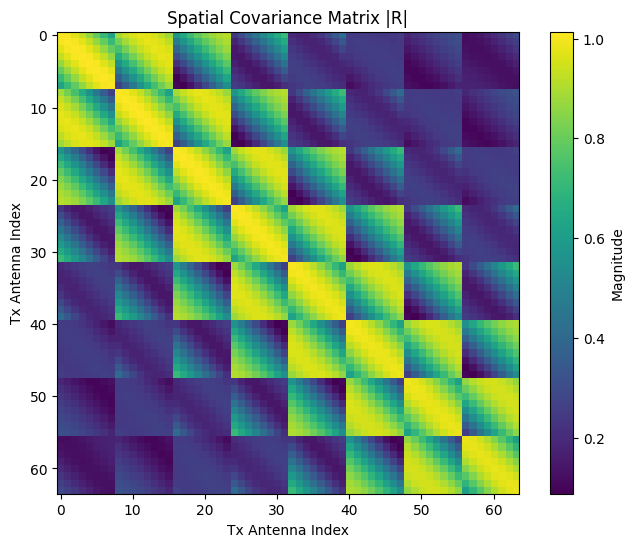

Saved dataset to data


In [5]:
plt.figure(figsize=(8, 6))
plt.imshow(np.abs(R_avg.numpy()), cmap='viridis')
plt.colorbar(label='Magnitude')
plt.title('Spatial Covariance Matrix |R|')
plt.xlabel('Tx Antenna Index')
plt.ylabel('Tx Antenna Index')
plt.show()

# Export data
save_dataset(h_tensor, R_matrix)
